# 03 – Baseline models

**Goal:** Build simple first models. Their scores are the standard that XGBoost (Day 2) must beat.

**Baseline** = a simple first model. Without it, an error like "$48,000" means nothing, because there's nothing to compare it with.

**Data:** all 8 features → `MedHouseVal` (in 100,000 USD). Same split as notebooks 01 and 02 (80/20, random_state=42).

In [1]:
import sklearn
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

print("scikit-learn:", sklearn.__version__)

housing_df = fetch_california_housing(as_frame=True).frame

feature_columns = housing_df.columns.drop("MedHouseVal")
X = housing_df[feature_columns]
y = housing_df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Features:", list(feature_columns))
print("Train:", X_train.shape, " Test:", X_test.shape)

scikit-learn: 1.9.1
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train: (16512, 8)  Test: (4128, 8)


## Regression baseline: StandardScaler + LinearRegression

**Pipeline** = scaler → model in one object. `.fit()` scales and trains; `.predict()` scales new data the same way.

**StandardScaler:** `scaled = (value − average) / spread`. 0 = average. Learned from the **train set only**, so there's no leakage.

We also measure the **training time**, which XGBoost will be compared on later.

In [2]:
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

baseline_regression_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

start_time = time.perf_counter()
baseline_regression_pipeline.fit(X_train, y_train)
regression_train_time_seconds = time.perf_counter() - start_time

fitted_linear_model = baseline_regression_pipeline.named_steps["model"]
print(f"Training time: {regression_train_time_seconds:.3f} seconds")
print("Bias (b):", round(fitted_linear_model.intercept_, 3))
print(pd.Series(fitted_linear_model.coef_, index=feature_columns).round(3))

Training time: 0.062 seconds
Bias (b): 2.072
MedInc        0.854
HouseAge      0.123
AveRooms     -0.294
AveBedrms     0.339
Population   -0.002
AveOccup     -0.041
Latitude     -0.897
Longitude    -0.870
dtype: float64


## Regression baseline: scores (5-fold cross-validation on the train set)

The test set is used only once, at the end, so we score on the train set with cross-validation.

- **MAE:** average error in $
- **RMSE:** like MAE, but big misses count extra. RMSE much bigger than MAE → a few very big misses
- **R²:** how much of the price the model explains (1.0 = perfect)

Price is in 100,000 USD, so we multiply by 100,000 to get $.
CHeckResults=The regression baseline (scaler + linear regression, all 8 features) is wrong by about $72k (RMSE) and $53k (MAE), and explains 61% of the price (R²). This is the standard XGBoost must beat with a clearly lower error. If it only matches it, the simpler baseline wins.

In [3]:
from sklearn.model_selection import cross_validate

regression_cv_results = cross_validate(
    baseline_regression_pipeline, X_train, y_train, cv=5,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    },
)

# Note: "test_" here means each held-out fold, NOT our real test set
baseline_cv_rmse = -regression_cv_results["test_rmse"].mean()
baseline_cv_mae = -regression_cv_results["test_mae"].mean()
baseline_cv_r2 = regression_cv_results["test_r2"].mean()

print(f"CV RMSE: {baseline_cv_rmse:.3f}  (≈ ${baseline_cv_rmse * 100_000:,.0f})")
print(f"CV MAE:  {baseline_cv_mae:.3f}  (≈ ${baseline_cv_mae * 100_000:,.0f})")
print(f"CV R²:   {baseline_cv_r2:.3f}")

CV RMSE: 0.721  (≈ $72,053)
CV MAE:  0.529  (≈ $52,906)
CV R²:   0.611


## Regression baseline: inference time

- **Training time** = how long the model takes to **learn**
- **Inference time** = how long it takes to **predict** for new areas

Inference time matters for the API (Day 4): every request waits for it.
We time predictions on the train rows (the test set stays hidden until the end).

In [4]:
start_time = time.perf_counter()
baseline_regression_pipeline.predict(X_train)
regression_inference_time_seconds = time.perf_counter() - start_time

milliseconds_per_1000_rows = regression_inference_time_seconds / len(X_train) * 1000 * 1000

print(f"Predicted {len(X_train):,} rows in {regression_inference_time_seconds:.4f} seconds")
print(f"≈ {milliseconds_per_1000_rows:.3f} ms per 1,000 rows")

Predicted 16,512 rows in 0.0038 seconds
≈ 0.233 ms per 1,000 rows


## Classification target: `expensive`

- **Regression** = predict a number (price). **Classification** = predict yes/no.
- `expensive = 1` if `MedHouseVal` > median price, else `0`.
- Median → about 50/50 split, so the model can't cheat by always saying "no".

**Leakage rules:**
1. `MedHouseVal` is NOT a feature (`expensive` is made from it).
2. The median is calculated on the **train set only**; the test set uses the same number.

In [5]:
median_price_train = y_train.median()

y_train_expensive = (y_train > median_price_train).astype(int)
y_test_expensive = (y_test > median_price_train).astype(int)

print(f"Median price (train): {median_price_train:.3f}  (≈ ${median_price_train * 100_000:,.0f})")
print("Train share expensive:")
print(y_train_expensive.value_counts(normalize=True).round(3))

Median price (train): 1.798  (≈ $179,850)
Train share expensive:
MedHouseVal
0    0.5
1    0.5
Name: proportion, dtype: float64


## Classification baseline: StandardScaler + LogisticRegression

**Logistic Regression** = the same sum as linear regression, squeezed into a probability (0–1). ≥ 0.5 → `expensive = 1`.

Scores (5-fold cross-validation on the train set):
- **Accuracy:** how many are right overall
- **Precision:** when it says "expensive", how often is it right? (low = many false alarms, FP)
- **Recall:** of the really expensive areas, how many did it find? (low = many misses, FN)
- **F1:** balance of precision and recall

In [6]:
from sklearn.linear_model import LogisticRegression

baseline_classification_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])

start_time = time.perf_counter()
baseline_classification_pipeline.fit(X_train, y_train_expensive)
classification_train_time_seconds = time.perf_counter() - start_time

classification_cv_results = cross_validate(
    baseline_classification_pipeline, X_train, y_train_expensive, cv=5,
    scoring=["accuracy", "precision", "recall", "f1"],
)

print(f"Training time: {classification_train_time_seconds:.3f} seconds")
for metric_name in ["accuracy", "precision", "recall", "f1"]:
    print(f"CV {metric_name}: {classification_cv_results['test_' + metric_name].mean():.3f}")
    

Training time: 0.036 seconds
CV accuracy: 0.828
CV precision: 0.827
CV recall: 0.830
CV f1: 0.828


## Classification baseline: confusion matrix

- **TP:** said expensive, really expensive ✅
- **TN:** said not, really not ✅
- **FP:** said expensive, really not ❌ (false alarm)
- **FN:** said not, really expensive ❌ (missed)

Name trick: 2nd word = what the model **said** (Positive = expensive), 1st word = was it **right**?

Predictions come from `cross_val_predict` on the train set, so each area is predicted by a model that didn't see it.

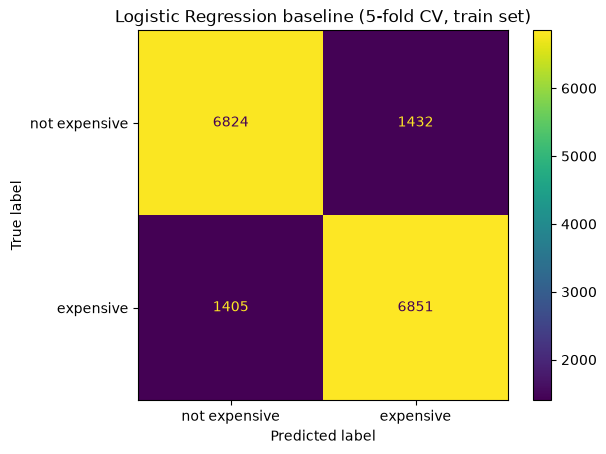

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

y_train_expensive_cv_predictions = cross_val_predict(
    baseline_classification_pipeline, X_train, y_train_expensive, cv=5
)

ConfusionMatrixDisplay.from_predictions(
    y_train_expensive, y_train_expensive_cv_predictions,
    display_labels=["not expensive", "expensive"],
)
plt.title("Logistic Regression baseline (5-fold CV, train set)")
plt.show()